<a href="https://colab.research.google.com/github/saraharshad101-sarah/Ames-House-Price-Regression/blob/main/Ames_House_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ames House Price Prediction

End-to-End Regression Project

This project develops a complete machine learning pipeline for predicting
house sale prices using the Ames Housing dataset.

## Project Stages
1. Exploratory Data Analysis
2. Data Cleaning and Feature Engineering
3. Regression Modeling
4. Model Evaluation and Interpretation

## 2. Exploratory Data Analysis

This section focuses on understanding the dataset's characteristics, identifying patterns, and detecting anomalies through various statistical and visualization techniques.

### 2.1 Dataset Overview

We start by loading the dataset and examining its initial structure and a sample of rows.

## 1. Project Overview

This section outlines the project goals and the overall structure of the machine learning pipeline.

In [25]:
import pandas as pd

df = pd.read_csv("/content/train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Here, we get a summary of the DataFrame, including data types and non-null counts for each column.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 2.2 Missing Values

Identifying and quantifying missing values is crucial for deciding on appropriate imputation strategies or whether to drop certain features.

In [27]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### 2.3 Correlation Analysis

We analyze the correlation of numerical features with the target variable, 'SalePrice', to understand their linear relationships. This helps in identifying potentially important features for our model.

In [28]:
correlations = df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)

correlations

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


Here are the top 10 features most correlated with 'SalePrice'.

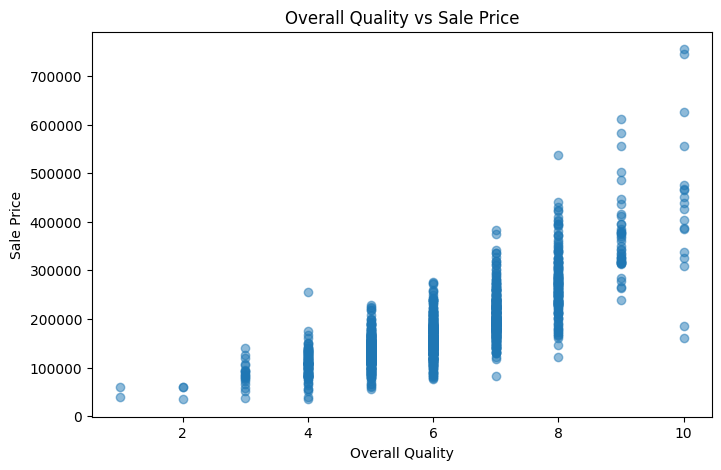

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["OverallQual"], df["SalePrice"], alpha=0.5)
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")
plt.show()


The distribution of `SalePrice` shows a right skew, indicating that most houses are priced lower, with fewer houses at very high prices.

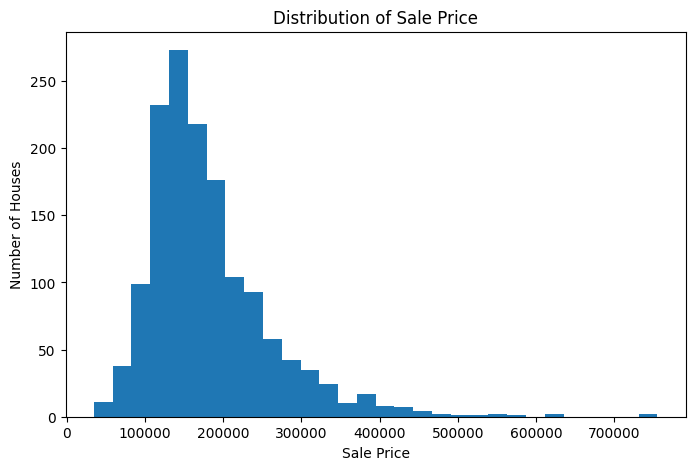

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Sale Price")
plt.show()

The box plot for `SalePrice` further illustrates the spread and highlights the presence of several outliers on the higher end of the price spectrum.

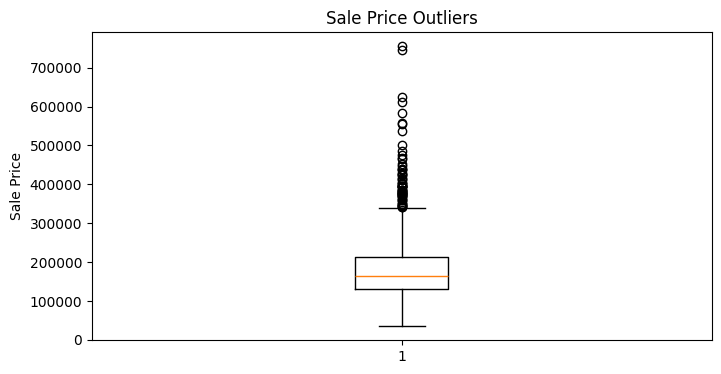

In [31]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["SalePrice"])
plt.ylabel("Sale Price")
plt.title("Sale Price Outliers")
plt.show()

This scatter plot between `GrLivArea` and `SalePrice` suggests a positive linear relationship, meaning larger living areas tend to correlate with higher sale prices. We can also observe some potential outliers.

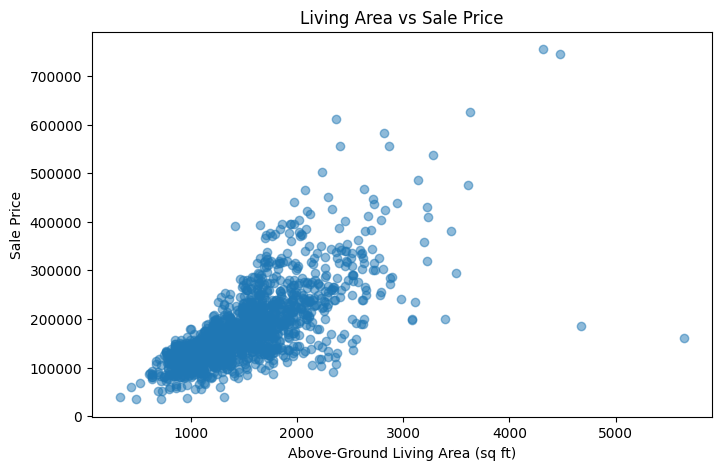

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()

We can also see a summary of the descriptive statistics for all numerical columns. This provides insights into the central tendency, dispersion, and shape of the data's distribution.

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 3. Data Cleaning and Feature Engineering

This stage involves preparing the data for modeling by handling missing values, creating new informative features, and separating the dataset into features and the target variable.

### 3.1 Remove Unnecessary Columns

We start by creating a copy of the original DataFrame to avoid modifying it directly and drop the 'Id' column, as it's just an identifier and not useful for prediction.

In [34]:
top_correlations = correlations.drop("SalePrice").abs().sort_values(ascending=False).head(10)

top_correlations

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


### 2.4 Distribution and Outlier Analysis

Visualizing the distribution of key variables and checking for outliers helps in understanding data spread and identifying potential issues that might affect model performance.

In [35]:
data = df.copy()

print("Original shape:", data.shape)

Original shape: (1460, 81)


In [36]:
data = data.drop(columns=["Id"])

print("New shape:", data.shape)

New shape: (1460, 80)


### 3.2 Feature Engineering

We create new features by combining existing ones or deriving new information that could be valuable for the model. These include `TotalSF` (total square footage), `TotalBathrooms`, `HouseAge`, and `RemodAge`.

In [37]:
data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]

data["TotalBathrooms"] = (
    data["FullBath"]
    + 0.5 * data["HalfBath"]
    + data["BsmtFullBath"]
    + 0.5 * data["BsmtHalfBath"]
)

data["HouseAge"] = data["YrSold"] - data["YearBuilt"]

data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]

print("New shape:", data.shape)

New shape: (1460, 84)


In [38]:
data[["TotalSF", "TotalBathrooms", "HouseAge", "RemodAge"]].describe()

,TotalSF,TotalBathrooms,HouseAge,RemodAge
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,2567.048630,2.210616,36.547945,22.950000
std,821.714421,0.785399,30.250152,20.640653
min,334.000000,1.000000,0.000000,-1.000000
25%,2009.500000,2.000000,8.000000,4.000000
50%,2474.000000,2.000000,35.000000,14.000000
75%,3004.000000,2.500000,54.000000,41.000000
max,11752.000000,6.000000,136.000000,60.000000


Some `RemodAge` values are negative, which indicates that `YearRemodAdd` is greater than `YrSold`. We will correct these by setting them to 0, implying the house was remodeled in the year it was sold or earlier.

In [39]:
data.loc[data["RemodAge"] < 0, ["YearRemodAdd", "YrSold", "RemodAge"]]


,YearRemodAdd,YrSold,RemodAge
523,2008,2007,-1


In [40]:
data.loc[data["RemodAge"] < 0, "RemodAge"] = 0

print("Negative RemodAge values:", (data["RemodAge"] < 0).sum())

Negative RemodAge values: 0


### 3.3 Missing Value Handling

We will now address the remaining missing values using appropriate imputation strategies based on the nature of each feature.

First, we re-examine the missing values after adding new features.

In [41]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


For categorical features where NaN likely means 'None' (e.g., no pool, no alley access), we fill the missing values with the string 'None'.

In [42]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence",
    "MasVnrType", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "BsmtQual", "BsmtCond"
]

data[none_cols] = data[none_cols].fillna("None")

print("Remaining missing values:", data.isnull().sum().sum())

Remaining missing values: 349


For `LotFrontage`, which is a numerical feature, we impute missing values with the median to avoid skewing the distribution with extreme values.

In [43]:
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

print("Missing LotFrontage:", data["LotFrontage"].isnull().sum())

Missing LotFrontage: 0


For `GarageYrBlt` and `MasVnrArea`, we fill missing values with 0, as this often indicates the absence of a garage or masonry veneer.

In [44]:
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0)
data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

print("Missing GarageYrBlt:", data["GarageYrBlt"].isnull().sum())
print("Missing MasVnrArea:", data["MasVnrArea"].isnull().sum())

Missing GarageYrBlt: 0
Missing MasVnrArea: 0


Before imputing `Electrical`, we inspect its value counts to determine the most frequent category for imputation.

In [45]:
print(data["Electrical"].value_counts())

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64


We fill the single missing value in the `Electrical` column with 'SBrkr', which is the most frequent category.

In [46]:
data["Electrical"] = data["Electrical"].fillna("SBrkr")

print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [47]:
missing = data.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)
print("\nTotal missing values:", data.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0


### 3.4 Feature and Target Separation

We separate the dataset into features (X) and the target variable (y), which is 'SalePrice'. We also identify numerical and categorical features for separate preprocessing steps.

In [48]:
X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 83)
Target shape: (1460,)


In [49]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical columns:")
print(list(categorical_features))

Numerical features: 40
Categorical features: 43

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


This check confirms that all features are either numeric or categorical and accounted for.

In [50]:
print("Total features:", X.shape[1])
print("Numeric + categorical:", len(numeric_features) + len(categorical_features))

Total features: 83
Numeric + categorical: 83


### 3.5 Preprocessing and Train-Test Split

We define a preprocessing pipeline using `ColumnTransformer` to apply `StandardScaler` to numerical features and `OneHotEncoder` to categorical features. Then, we split the data into training and testing sets.

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


The data is split into training and testing sets to evaluate the model's performance on unseen data. 80% of the data is used for training, and 20% for testing.

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (1168, 83)
Test features: (292, 83)
Training target: (1168,)
Test target: (292,)


## 4. Regression Modeling

This section involves building and training regression models to predict house prices, starting with a baseline model and then moving to a more advanced one.

### 4.1 Baseline Linear Regression

We establish a baseline model using `LinearRegression` combined with our preprocessing pipeline. This model serves as a reference point for evaluating more complex models.

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

print("Baseline model created.")

Baseline model created.


The baseline model is trained using the preprocessed training data.

In [54]:
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


After training, we make predictions on the test set.

In [55]:
y_pred_baseline = baseline_model.predict(X_test)

print("Number of predictions:", len(y_pred_baseline))
print("First 5 predictions:", y_pred_baseline[:5])

Number of predictions: 292
First 5 predictions: [159671.86407858 336366.18340382  93920.81504122 173807.52080121
 326662.72953168]


We evaluate the baseline model's performance using RMSE, MAE, and R² metrics. We also identify the prediction with the lowest predicted value to investigate potential issues.

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Linear Regression")
print("RMSE:", round(baseline_rmse, 2))
print("MAE:", round(baseline_mae, 2))
print("R²:", round(baseline_r2, 4))
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_baseline
})

comparison.head(10)
print(comparison.describe())
comparison.loc[comparison["Predicted"].idxmin()]

Baseline Linear Regression
RMSE: 95748.93
MAE: 23356.5
R²: -0.1952
              Actual     Predicted
count     292.000000  2.920000e+02
mean   178839.811644  1.726650e+05
std     87730.751259  1.229315e+05
min     35311.000000 -1.386705e+06
25%    127000.000000  1.228933e+05
50%    154150.000000  1.566334e+05
75%    209175.000000  2.140410e+05
max    755000.000000  5.747847e+05


,193
Actual,1.710000e+05
Predicted,-1.386705e+06


In [67]:
problem_position = comparison["Predicted"].values.argmin()

problem_index = X_test.index[problem_position]

print("Test-set position:", problem_position)
print("Original dataset index:", problem_index)
X_test.loc[problem_index]
problem_house = X_test.loc[[problem_index]]

problem_house.select_dtypes(include=["number"]).T

Test-set position: 193
Original dataset index: 1170


,1170
MSSubClass,80.0
LotFrontage,76.0
LotArea,9880.0
OverallQual,6.0
OverallCond,6.0
YearBuilt,1977.0
YearRemodAdd,1977.0
MasVnrArea,0.0
BsmtFinSF1,522.0
BsmtFinSF2,0.0


### 4.2 Ridge Regression

Ridge Regression is introduced as an alternative model, often performing better than plain Linear Regression by adding L2 regularization to prevent overfitting.

In [68]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

print("Ridge model pipeline created.")

Ridge model pipeline created.


### 4.3 Hyperparameter Tuning

We use `GridSearchCV` to find the optimal `alpha` hyperparameter for the Ridge Regression model. This involves training the model with various `alpha` values and selecting the one that yields the best cross-validation performance.

In [69]:
from sklearn.model_selection import GridSearchCV

alpha_values = [0.01, 0.1, 1, 10, 100, 1000]

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={"regressor__alpha": alpha_values},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Ridge cross-validation setup complete.")

Ridge cross-validation setup complete.


The `GridSearchCV` is fitted to the training data to find the best `alpha` value for the Ridge model.

In [70]:
ridge_grid.fit(X_train, y_train)

print("Best alpha:", ridge_grid.best_params_["regressor__alpha"])
print("Best CV RMSE:", round(-ridge_grid.best_score_, 2))

Best alpha: 10
Best CV RMSE: 32634.56


## 5. Model Evaluation

This section compares the performance of the trained models and analyzes their predictions and residuals to assess their accuracy and reliability.

### 5.1 Performance Comparison

We evaluate the Ridge Regression model's performance on the test set and compare it against the baseline Linear Regression model using RMSE, MAE, and R² metrics.

In [71]:
y_pred_ridge = ridge_grid.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("RMSE:", round(ridge_rmse, 2))
print("MAE:", round(ridge_mae, 2))
print("R²:", round(ridge_r2, 4))

Ridge Regression
RMSE: 30535.73
MAE: 19175.49
R²: 0.8784


In [72]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [baseline_rmse, ridge_rmse],
    "MAE": [baseline_mae, ridge_mae],
    "R²": [baseline_r2, ridge_r2]
})

results

,Model,RMSE,MAE,R²
0,Linear Regression,95748.933727,23356.495434,-0.195237
1,Ridge Regression,30535.729900,19175.486803,0.878437


### 5.2 Actual vs Predicted Prices

This scatter plot visualizes the actual `SalePrice` against the predicted `SalePrice` from the Ridge Regression model. A perfect model's predictions would fall on the dashed diagonal line.

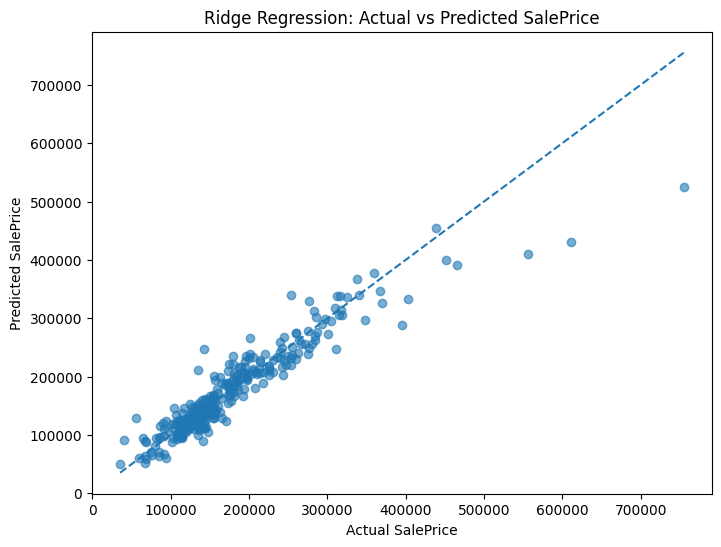

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Ridge Regression: Actual vs Predicted SalePrice")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

### 5.3 Residual Analysis

The residual plot helps in checking the assumptions of the regression model. Ideally, residuals should be randomly distributed around zero, with no clear patterns or trends.

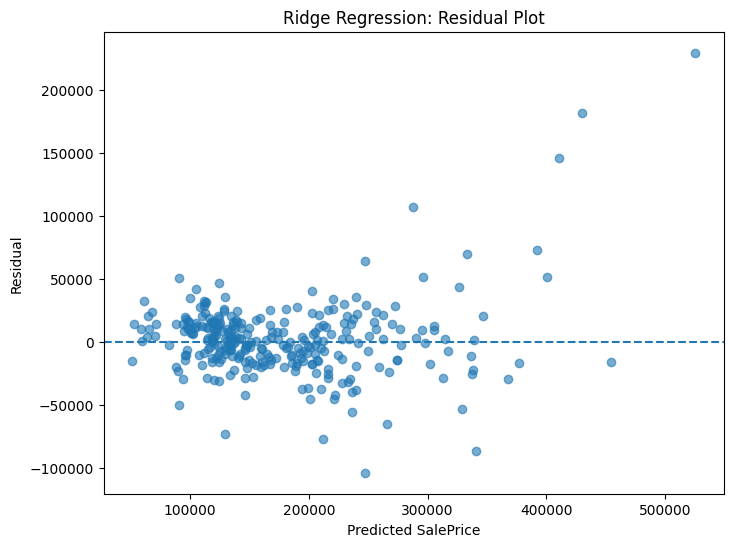

In [74]:
residuals = y_test - y_pred_ridge

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ridge, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Ridge Regression: Residual Plot")

plt.show()

## 6. Results and Conclusion

In [75]:
top_correlations

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101
